# Characterization physical-correctness gate

Before Phase 1 (per-cell BOL identification), verify each cell's characterization scalars are inside physical bounds. Any cell that fails a hard bound gets excluded from calibration. Source: `characterization_results.csv` (pre-processed by `pyspark-incremental-1.0`, exported from `characterization_database.rd_characterization`).

**Scope**: CALB + REPT + EVE only. Other cohorts (HIGHSTAR/CLEVA/GOTION/LICR) dropped.

**Rule of engagement**: one check per section. Each section produces a table of flagged cells + a plot. No cell is used downstream unless it passes every hard bound.

In [1]:
from pathlib import Path
import ast

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

SRC = Path('/home/hj/Desktop/PINNs/characterization_results.csv')
MAKES = ['CALB', 'REPT', 'EVE']
COLOR = {'CALB': '#c94a3c', 'REPT': '#3c7cc9', 'EVE': '#4dab5c'}

# Nameplate capacity per make (from CSV `max_cap` string field)
NAMEPLATE = {'CALB': 72.0, 'REPT': 150.0, 'EVE': 105.0}

df = pd.read_csv(SRC)
df = df[df['make'].isin(MAKES)].copy()
df['cell'] = df['cell'].astype(str).str.zfill(4)
df['batch'] = df['batch'].astype(int)
df['nameplate_ah'] = df['make'].map(NAMEPLATE)
print(f'Rows in scope: {len(df)} across {df["make"].value_counts().to_dict()}')
display(df.groupby(['make','batch']).size().unstack(fill_value=0))

Rows in scope: 86 across {'REPT': 51, 'CALB': 27, 'EVE': 8}


batch,1,2,3
make,,,
CALB,0,27,0
EVE,8,0,0
REPT,21,26,4


In [2]:
# Array-valued columns are stored as Python-list repr strings — parse them.
ARRAY_COLS = [
    'rate_cap_c_rates', 'rate_cap_q_curve',
    'rate_cap_c_rates_chg', 'rate_cap_q_chg_curve',
    'const_power_levels_w', 'const_power_t_dis_curve', 'const_power_energy_curve',
    'ocv_soc_grid', 'v_oc_curve', 'ocv_soc_grid_chg', 'v_oc_chg_curve',
    'dcir_soc_nominal', 'dcir_soc_at_pulse', 'dcir_i_at_pulse', 'r_dc_curve',
    'peak_power_soc_grid', 'p_peak_10s_dchg_curve', 'p_peak_10s_chg_curve',
    'hppc_soc_at_pulse_dchg', 'hppc_i_at_pulse_dchg',
    'r0_dchg_curve', 'r1_dchg_curve', 'c1_dchg_curve', 'r2_dchg_curve', 'c2_dchg_curve',
    'gitt_soc_grid', 'r_pulse_curve', 'tau_diff_curve', 'v_inf_curve',
]

def _parse(x):
    if isinstance(x, float) and np.isnan(x):
        return None
    if isinstance(x, str):
        try:
            return np.array(ast.literal_eval(x), dtype=float)
        except Exception:
            return None
    return x

for c in ARRAY_COLS:
    if c in df.columns:
        df[c] = df[c].apply(_parse)

# Sanity: how many rows have each characterization block populated?
blocks = {
    'RPT capacity (q_rpt_ah)': df['q_rpt_ah'].notna(),
    'OCV discharge (v_oc_curve)': df['v_oc_curve'].apply(lambda a: isinstance(a, np.ndarray) and a.size > 5),
    'DCIR (r_dc_curve)': df['r_dc_curve'].apply(lambda a: isinstance(a, np.ndarray) and a.size > 0),
    'HPPC R0 (r0_dchg_curve)': df['r0_dchg_curve'].apply(lambda a: isinstance(a, np.ndarray) and a.size > 0),
    'HPPC R1 (r1_dchg_curve)': df['r1_dchg_curve'].apply(lambda a: isinstance(a, np.ndarray) and a.size > 0),
    'GITT tau_diff (tau_diff_curve)': df['tau_diff_curve'].apply(lambda a: isinstance(a, np.ndarray) and a.size > 0),
    'Self-discharge (dsoc_per_day)': df['self_disch_dsoc_per_day'].notna(),
}
cov = pd.DataFrame({
    b: {m: int(mask[df['make']==m].sum()) for m in MAKES}
    for b, mask in blocks.items()
}).T
cov.columns = MAKES
cov['total (of ' + str(len(df)) + ')'] = cov.sum(axis=1)
display(Markdown('### Characterization block coverage per make'))
display(cov)

### Characterization block coverage per make

,CALB,REPT,EVE,total (of 86)
RPT capacity (q_rpt_ah),27,47,8,82
OCV discharge (v_oc_curve),27,47,8,82
DCIR (r_dc_curve),26,26,8,60
HPPC R0 (r0_dchg_curve),26,47,8,81
HPPC R1 (r1_dchg_curve),26,47,8,81
GITT tau_diff (tau_diff_curve),26,21,6,53
Self-discharge (dsoc_per_day),19,47,4,70


## 1. Batch semantics — before or after aging?

For each make, look at `test_session_start` + RPT capacity per batch, per cell. If batch=2 sessions are later than batch=1 AND capacity dropped, batches represent characterization at different aging states. If batch=2 sessions overlap batch=1 or capacity is the same, they're reruns of the same state.

In [3]:
df['session_start'] = pd.to_datetime(df['test_session_start'], errors='coerce')

for make in MAKES:
    sub = df[df['make'] == make].copy()
    if sub['batch'].nunique() < 2:
        continue
    piv = sub.pivot_table(index='cell', columns='batch',
                          values=['session_start', 'q_rpt_ah'],
                          aggfunc='first')
    display(Markdown(f'### {make} — session date and Q_rpt per batch'))
    display(piv.head(30))
    # Delta-Q batch-over-batch
    if 1 in piv['q_rpt_ah'].columns and 2 in piv['q_rpt_ah'].columns:
        delta_q = (piv['q_rpt_ah'][2] - piv['q_rpt_ah'][1]).dropna()
        if len(delta_q):
            print(f'{make}: Q batch2 - batch1 stats (Ah)')
            print(f'  median: {delta_q.median():+.3f}')
            print(f'  min:    {delta_q.min():+.3f}')
            print(f'  max:    {delta_q.max():+.3f}')
            print(f'  n cells with both batches: {len(delta_q)}')

### REPT — session date and Q_rpt per batch

q_rpt_ah                    session_start                          \
batch        1        2                       1                       2   
cell                                                                      
0001   151.684  149.558 2025-10-10 14:59:13.470 2026-04-07 15:55:39.067   
0002       NaN  148.817                     NaT 2026-04-07 15:55:38.677   
0003   152.511  149.985 2025-10-10 14:59:13.322 2026-04-07 15:55:36.404   
0004   153.544  152.210 2025-10-10 14:59:13.394 2026-04-07 15:55:36.458   
0007   148.185  145.050 2025-10-10 14:59:25.522 2026-04-07 15:55:36.774   
0011   153.285  150.288 2025-10-10 14:59:37.111 2026-04-07 15:55:36.818   
0012   148.792  148.787 2025-10-10 14:59:37.143 2026-04-07 15:55:36.963   
0025   149.594  150.840 2025-10-10 15:00:36.670 2026-04-07 15:55:37.003   
0028       NaN  146.944                     NaT 2026-02-24 17:27:11.307   
0031       NaN  151.613                     NaT 2026-04-07 15:55:39.193   
0032       NaN  149.307                     NaT 2026-04-07 15:55:39.354   
0034   150.509  148.220 2025-10-10 15:01:02.688 2026-04-14 10:12:43.370   
0037       NaN  148.162                     NaT 2026-02-24 17:27:11.587   
0040   153.306  148.815 2025-10-10 15:01:31.899 2026-04-07 15:55:38.214   
0043   154.230  150.428 2025-10-10 15:01:42.057 2026-02-24 17:27:10.573   
0046   153.734  153.657 2025-10-10 15:01:53.148 2026-04-07 15:55:37.335   
0049   148.555  147.154 2025-10-10 15:02:05.204 2026-04-07 15:55:37.962   
0050   146.553  145.989 2025-10-10 15:02:05.058 2026-04-07 15:55:37.681   
0056   153.003  150.358 2025-10-10 15:02:14.198 2026-04-07 15:55:37.804   
0057   145.869  143.804 2025-10-10 15:02:35.204 2026-02-24 17:27:10.803   
0065   153.699  149.216 2025-10-10 15:03:27.720 2026-02-24 17:27:11.152   
0074   153.505  149.751 2025-10-10 15:03:48.366 2026-02-24 17:27:11.206   
0078   153.623  149.538 2025-10-10 15:03:59.155 2026-04-07 15:55:38.151   
0080   147.865  149.887 2025-10-10 15:04:11.657 2026-04-07 15:55:37.578   
0087   155.013  151.439 2025-10-10 15:04:22.488 2026-04-07 15:55:38.534   
0090   147.757  146.910 2025-10-10 15:04:34.288 2026-04-07 15:55:38.641   

                               
batch                       3  
cell                           
0001                      NaT  
0002                      NaT  
0003                      NaT  
0004                      NaT  
0007                      NaT  
0011                      NaT  
0012                      NaT  
0025                      NaT  
0028  2026-04-20 09:55:04.944  
0031                      NaT  
0032                      NaT  
0034                      NaT  
0037                      NaT  
0040                      NaT  
0043                      NaT  
0046                      NaT  
0049                      NaT  
0050                      NaT  
0056                      NaT  
0057  2026-04-20 09:55:04.041  
0065  2026-04-20 09:55:04.493  
0074  2026-04-20 09:55:04.606  
0078                      NaT  
0080                      NaT  
0087                      NaT  
0090                      NaT

REPT: Q batch2 - batch1 stats (Ah)
  median: -2.289
  min:    -4.491
  max:    +2.022
  n cells with both batches: 21


## 2. RPT capacity vs nameplate

**Hard bounds**: 0.40 * nameplate ≤ q_rpt_ah ≤ 1.05 * nameplate.

- Below 40% — cell too aged to be a useful second-life target (matches your SoH_first ≥ 0.60 filter approximately, given SoH ~ Q/Q_nameplate).
- Above 105% — measurement artifact (over-charged, RPT protocol error) — untrustable characterization.

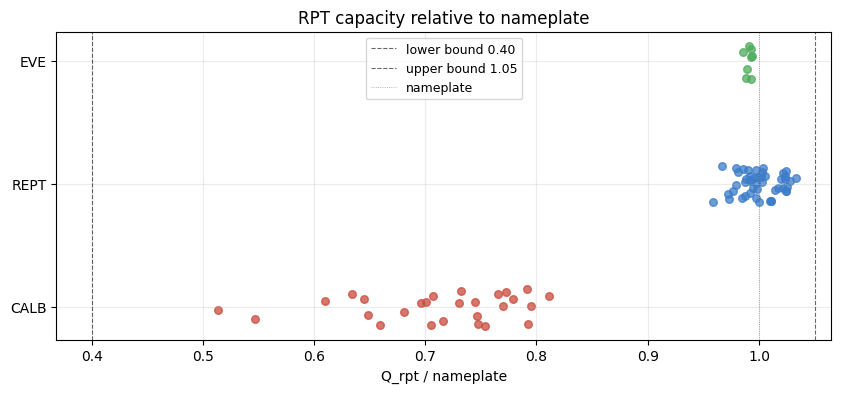

### Flagged (out of [0.40, 1.05] × nameplate): 0 rows

,make,cell,batch,q_rpt_ah,nameplate_ah,q_over_nameplate


In [4]:
df['q_over_nameplate'] = df['q_rpt_ah'] / df['nameplate_ah']
df['flag_q_low']  = df['q_over_nameplate'] < 0.40
df['flag_q_high'] = df['q_over_nameplate'] > 1.05

fig, ax = plt.subplots(figsize=(10, 4))
for m in MAKES:
    sub = df[df['make'] == m]
    y = np.array([MAKES.index(m)] * len(sub)) + np.random.default_rng(0).uniform(-0.15, 0.15, len(sub))
    ax.scatter(sub['q_over_nameplate'], y, color=COLOR[m], alpha=0.75, s=30)
ax.axvline(0.40, ls='--', color='k', lw=0.8, alpha=0.6, label='lower bound 0.40')
ax.axvline(1.05, ls='--', color='k', lw=0.8, alpha=0.6, label='upper bound 1.05')
ax.axvline(1.00, ls=':',  color='k', lw=0.6, alpha=0.4, label='nameplate')
ax.set_yticks(range(len(MAKES))); ax.set_yticklabels(MAKES)
ax.set_xlabel('Q_rpt / nameplate'); ax.set_title('RPT capacity relative to nameplate')
ax.legend(fontsize=9)
ax.grid(alpha=0.25); plt.show()

flags = df[df['flag_q_low'] | df['flag_q_high']][['make','cell','batch','q_rpt_ah','nameplate_ah','q_over_nameplate']]
display(Markdown(f'### Flagged (out of [0.40, 1.05] × nameplate): {len(flags)} rows'))
display(flags.reset_index(drop=True))

## 3. OCV curves — shape + LFP plateau

**Hard bounds** on the discharge OCV curve (`v_oc_curve` vs `ocv_soc_grid`):
- V at SoC=1.0 in [3.35, 3.75] V — top-of-charge before knee.
- V at SoC=0.0 in [2.30, 2.90] V — bottom-of-discharge.
- V at SoC=0.5 in [3.15, 3.35] V — LFP plateau.
- Curve strictly non-decreasing (monotone). LFP OCV can never rise with lower SoC.

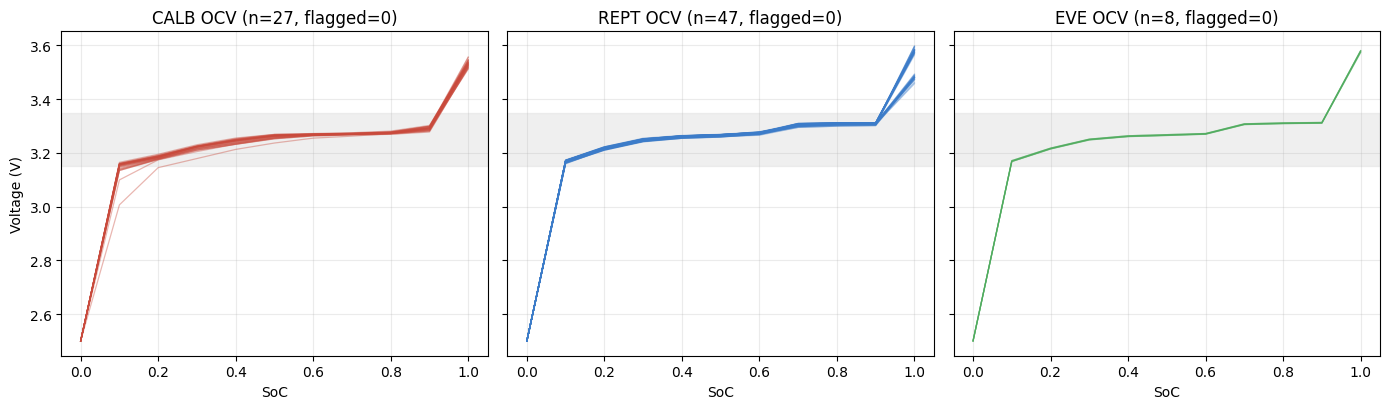

### OCV-flagged rows: 4

,make,cell,batch,v_top,v_bot,v_plat,monotone
0,REPT,0028,3,NaN,NaN,NaN,None
1,REPT,0074,3,NaN,NaN,NaN,None
2,REPT,0065,3,NaN,NaN,NaN,None
3,REPT,0057,3,NaN,NaN,NaN,None


In [5]:
def _ocv_bounds_row(row):
    grid = row['ocv_soc_grid']; v = row['v_oc_curve']
    if not (isinstance(grid, np.ndarray) and isinstance(v, np.ndarray) and len(grid) == len(v) and len(grid) > 3):
        return dict(v_top=np.nan, v_bot=np.nan, v_plat=np.nan, monotone=None, has_curve=False)
    order = np.argsort(grid); g = grid[order]; vv = v[order]
    v_top  = float(np.interp(1.0, g, vv))
    v_bot  = float(np.interp(0.0, g, vv))
    v_plat = float(np.interp(0.5, g, vv))
    # non-decreasing with SoC?
    monotone = bool(np.all(np.diff(vv) >= -1e-3))
    return dict(v_top=v_top, v_bot=v_bot, v_plat=v_plat, monotone=monotone, has_curve=True)

ocv_stats = pd.DataFrame([_ocv_bounds_row(r) for _, r in df.iterrows()])
ocv_stats.index = df.index
for c in ['v_top', 'v_bot', 'v_plat', 'monotone', 'has_curve']:
    df[c] = ocv_stats[c]

df['flag_v_top']  = ~df['v_top'].between(3.35, 3.75)  | df['v_top'].isna()
df['flag_v_bot']  = ~df['v_bot'].between(2.30, 2.90)  | df['v_bot'].isna()
df['flag_v_plat'] = ~df['v_plat'].between(3.15, 3.35) | df['v_plat'].isna()
df['flag_ocv_nonmonotone'] = df['monotone'] == False

# Plot every OCV curve, colored by make; highlight flagged
fig, axes = plt.subplots(1, len(MAKES), figsize=(14, 4.2), sharey=True)
for ax, m in zip(axes, MAKES):
    sub = df[df['make'] == m]
    n_curves = 0; n_flagged = 0
    for _, r in sub.iterrows():
        if not r['has_curve']: continue
        g = r['ocv_soc_grid']; v = r['v_oc_curve']
        order = np.argsort(g); g = g[order]; v = v[order]
        flagged = r['flag_v_top'] or r['flag_v_bot'] or r['flag_v_plat'] or r['flag_ocv_nonmonotone']
        ax.plot(g, v, color=('red' if flagged else COLOR[m]),
                 alpha=(0.9 if flagged else 0.4), lw=(1.3 if flagged else 0.9))
        n_curves += 1; n_flagged += int(flagged)
    ax.axhspan(3.15, 3.35, color='0.85', alpha=0.4)
    ax.set_xlabel('SoC'); ax.set_title(f'{m} OCV (n={n_curves}, flagged={n_flagged})')
    ax.grid(alpha=0.25)
axes[0].set_ylabel('Voltage (V)')
plt.tight_layout(); plt.show()

ocv_flags = df[df['flag_v_top'] | df['flag_v_bot'] | df['flag_v_plat'] | df['flag_ocv_nonmonotone']]
display(Markdown(f'### OCV-flagged rows: {len(ocv_flags)}'))
display(ocv_flags[['make','cell','batch','v_top','v_bot','v_plat','monotone']].reset_index(drop=True))

## 4. HPPC R0 — ohmic resistance vs SoC

**Hard bounds** on `r0_dchg_curve` (mΩ per SoC point):
- Range: 0.3 mΩ ≤ R0 ≤ 4.0 mΩ for LFP cells of this size (72–150 Ah).
- All entries finite (no NaN in populated rows).
- Shape: mild U-shape vs SoC is expected; strictly monotonic is fine but a huge spike would be suspicious.

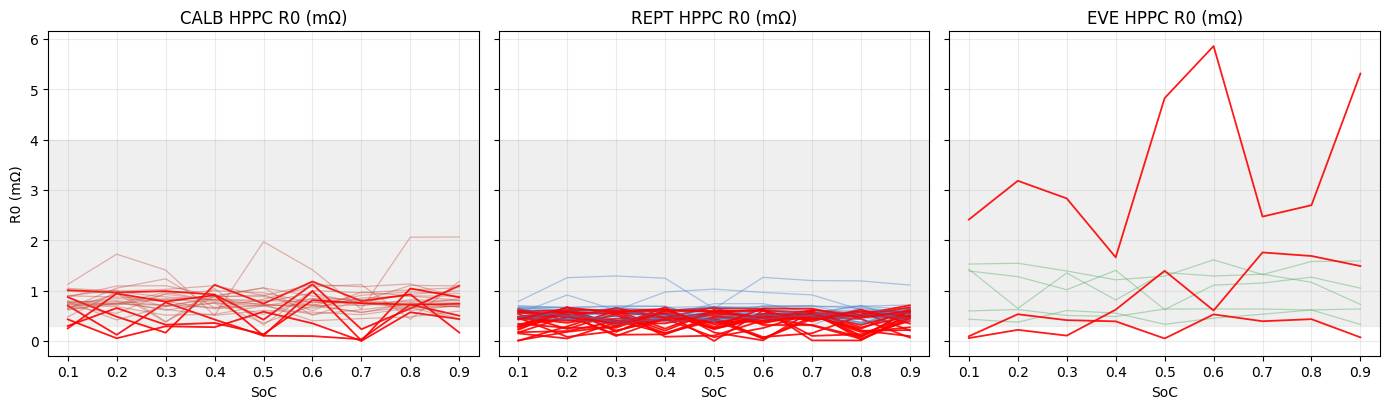

### HPPC R0 flags: 39

,make,cell,batch,r0_min,r0_max,r0_median,has
0,CALB,0006,2,0.034112,0.764910,0.426956,True
1,REPT,0031,2,0.046734,0.550316,0.449875,True
2,REPT,0049,2,0.052187,0.507008,0.406273,True
3,REPT,0043,2,0.075935,0.606732,0.417101,True
4,EVE,0001,1,0.049791,0.531191,0.392750,True
5,REPT,0028,3,NaN,NaN,NaN,False
6,REPT,0003,2,0.178896,0.535355,0.433755,True
7,REPT,0074,3,NaN,NaN,NaN,False
8,CALB,0009,2,0.001028,0.581932,0.350426,True
9,REPT,0087,2,0.082055,0.490608,0.461169,True


In [6]:
def _hppc_r0_stats(a):
    if not isinstance(a, np.ndarray) or a.size == 0: return dict(r0_min=np.nan, r0_max=np.nan, r0_median=np.nan, has=False)
    return dict(r0_min=float(np.nanmin(a)), r0_max=float(np.nanmax(a)),
                r0_median=float(np.nanmedian(a)), has=True)

hppc_stats = pd.DataFrame([_hppc_r0_stats(r) for r in df['r0_dchg_curve']])
hppc_stats.index = df.index
for c in ['r0_min','r0_max','r0_median','has']:
    df[c] = hppc_stats[c]
df['flag_r0_low']  = df['r0_min']    < 0.3
df['flag_r0_high'] = df['r0_max']    > 4.0
df['flag_r0_absent'] = df['has'] == False

fig, axes = plt.subplots(1, len(MAKES), figsize=(14, 4.2), sharey=True)
for ax, m in zip(axes, MAKES):
    sub = df[df['make'] == m]
    for _, r in sub.iterrows():
        a = r['r0_dchg_curve']; g = r['hppc_soc_at_pulse_dchg']
        if not isinstance(a, np.ndarray) or not isinstance(g, np.ndarray): continue
        flagged = r['flag_r0_low'] or r['flag_r0_high']
        ax.plot(g, a, color=('red' if flagged else COLOR[m]),
                alpha=(0.9 if flagged else 0.4), lw=(1.3 if flagged else 0.9))
    ax.axhspan(0.3, 4.0, color='0.85', alpha=0.4)
    ax.set_xlabel('SoC'); ax.set_title(f'{m} HPPC R0 (mΩ)')
    ax.grid(alpha=0.25)
axes[0].set_ylabel('R0 (mΩ)')
plt.tight_layout(); plt.show()

r0_flags = df[df['flag_r0_low'] | df['flag_r0_high'] | df['flag_r0_absent']]
display(Markdown(f'### HPPC R0 flags: {len(r0_flags)}'))
display(r0_flags[['make','cell','batch','r0_min','r0_max','r0_median','has']].reset_index(drop=True))

## 5. GITT diffusion time constant

**Hard bounds** on `tau_diff_curve` (seconds):
- 10 s ≤ tau_diff ≤ 10,000 s across the SoC grid. Below 10 s is unphysically fast for solid-phase Li diffusion; above 10,000 s suggests a pulse-length or fitting artifact.

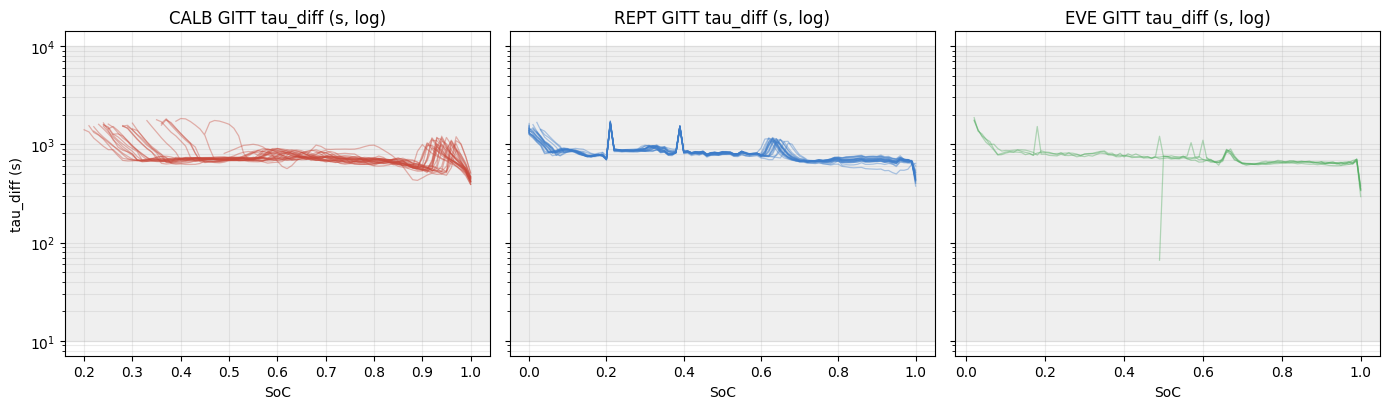

### GITT tau_diff flags: 33

,make,cell,batch,tau_min,tau_max,tau_median
0,REPT,0040,2,NaN,NaN,NaN
1,REPT,0031,2,NaN,NaN,NaN
2,REPT,0057,2,NaN,NaN,NaN
3,EVE,0003,1,NaN,NaN,NaN
4,REPT,0049,2,NaN,NaN,NaN
5,REPT,0002,2,NaN,NaN,NaN
6,REPT,0025,2,NaN,NaN,NaN
7,REPT,0043,2,NaN,NaN,NaN
8,EVE,0001,1,NaN,NaN,NaN
9,REPT,0090,2,NaN,NaN,NaN


In [7]:
def _tau_stats(a):
    if not isinstance(a, np.ndarray) or a.size == 0: return dict(tau_min=np.nan, tau_max=np.nan, tau_median=np.nan, has=False)
    return dict(tau_min=float(np.nanmin(a)), tau_max=float(np.nanmax(a)), tau_median=float(np.nanmedian(a)), has=True)

tau_stats = pd.DataFrame([_tau_stats(r) for r in df['tau_diff_curve']])
tau_stats.index = df.index
for c in ['tau_min','tau_max','tau_median']:
    df[c] = tau_stats[c]
df['flag_tau_low']  = df['tau_min'] < 10.0
df['flag_tau_high'] = df['tau_max'] > 10000.0
df['flag_tau_absent'] = tau_stats['has'] == False

fig, axes = plt.subplots(1, len(MAKES), figsize=(14, 4.2), sharey=True)
for ax, m in zip(axes, MAKES):
    sub = df[df['make'] == m]
    for _, r in sub.iterrows():
        a = r['tau_diff_curve']; g = r['gitt_soc_grid']
        if not isinstance(a, np.ndarray) or not isinstance(g, np.ndarray): continue
        flagged = r['flag_tau_low'] or r['flag_tau_high']
        ax.plot(g, a, color=('red' if flagged else COLOR[m]),
                alpha=(0.9 if flagged else 0.4), lw=(1.3 if flagged else 0.9))
    ax.axhspan(10, 10000, color='0.85', alpha=0.4)
    ax.set_yscale('log')
    ax.set_xlabel('SoC'); ax.set_title(f'{m} GITT tau_diff (s, log)')
    ax.grid(alpha=0.25, which='both')
axes[0].set_ylabel('tau_diff (s)')
plt.tight_layout(); plt.show()

tau_flags = df[df['flag_tau_low'] | df['flag_tau_high'] | df['flag_tau_absent']]
display(Markdown(f'### GITT tau_diff flags: {len(tau_flags)}'))
display(tau_flags[['make','cell','batch','tau_min','tau_max','tau_median']].reset_index(drop=True))

## 6. Self-discharge

**Hard bounds** on `self_disch_dsoc_per_day` (fraction of SoC per day):
- 1e-4 ≤ dSoC/day ≤ 5e-3 at 25 °C for LFP.
- Below 1e-4 → suspiciously good, may indicate a fitting failure.
- Above 5e-3 → high but plausible for aged/damaged cells; flag as warning.

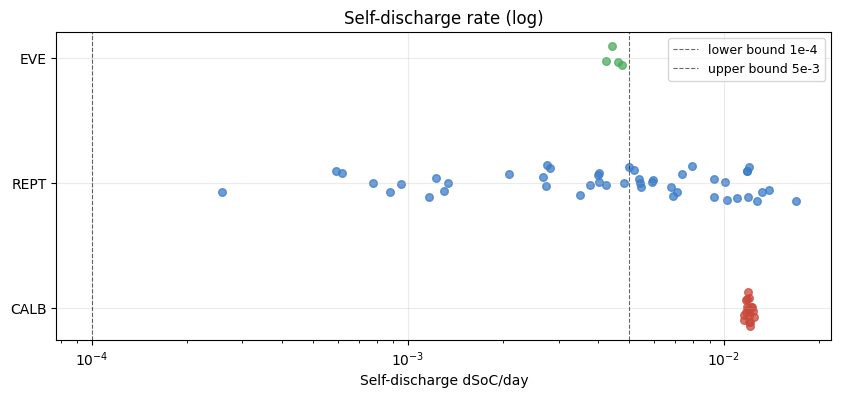

### Self-discharge flags: 43

,make,cell,batch,self_disch_dsoc_per_day,self_disch_ambient_c
0,REPT,0040,2,0.011968,25.0
1,REPT,0031,2,0.009276,25.0
2,REPT,0049,2,0.013916,25.0
3,REPT,0002,2,0.011798,25.0
4,REPT,0025,2,0.005454,25.0
5,REPT,0043,2,0.010067,25.0
6,REPT,0090,2,0.016899,25.0
7,REPT,0003,2,0.005896,25.0
8,CALB,0002,2,0.012122,25.0
9,CALB,0012,2,0.011870,25.0


In [8]:
sd = df[['make','cell','batch','self_disch_dsoc_per_day','self_disch_ambient_c']].dropna(subset=['self_disch_dsoc_per_day'])
df['flag_sd_low']  = df['self_disch_dsoc_per_day'] < 1e-4
df['flag_sd_high'] = df['self_disch_dsoc_per_day'] > 5e-3

fig, ax = plt.subplots(figsize=(10, 4))
for m in MAKES:
    sub = df[df['make'] == m]
    y = np.array([MAKES.index(m)] * len(sub)) + np.random.default_rng(1).uniform(-0.15, 0.15, len(sub))
    ax.scatter(sub['self_disch_dsoc_per_day'], y, color=COLOR[m], alpha=0.75, s=30)
ax.axvline(1e-4, ls='--', color='k', lw=0.8, alpha=0.6, label='lower bound 1e-4')
ax.axvline(5e-3, ls='--', color='k', lw=0.8, alpha=0.6, label='upper bound 5e-3')
ax.set_xscale('log'); ax.set_xlabel('Self-discharge dSoC/day')
ax.set_yticks(range(len(MAKES))); ax.set_yticklabels(MAKES)
ax.set_title('Self-discharge rate (log)')
ax.legend(fontsize=9); ax.grid(alpha=0.25)
plt.show()

sd_flags = df[df['flag_sd_low'] | df['flag_sd_high']][['make','cell','batch','self_disch_dsoc_per_day','self_disch_ambient_c']]
display(Markdown(f'### Self-discharge flags: {len(sd_flags)}'))
display(sd_flags.reset_index(drop=True))

## 7. Cross-check: HPPC R0 vs DCIR R0 at same SoC

HPPC and DCIR are two independent measurements of the same physical resistance at the same SoC. If they disagree by more than ~30% at overlapping SoC points, one of the two extractions is wrong.

(Only rows that have both `r0_dchg_curve` (HPPC) AND `r_dc_curve` (DCIR) populated.)

### HPPC vs DCIR consistency (n=54 rows had both)

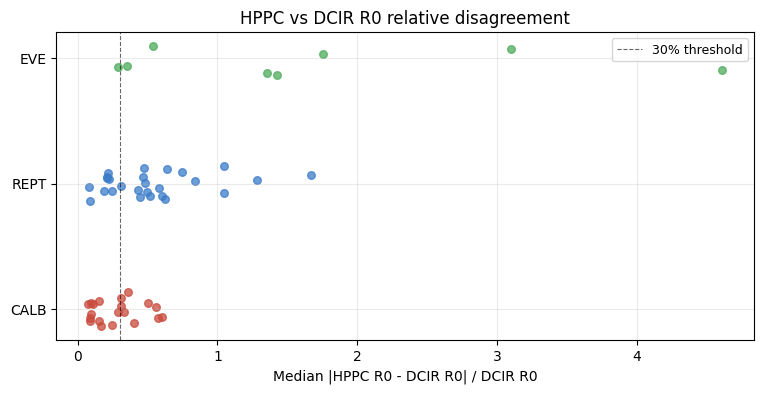

,make,cell,batch,median_rel_err,max_rel_err,n_soc,flag_disagree
0,CALB,0006,2,0.576088,0.961530,4,True
1,REPT,0040,2,1.048094,1.874738,5,True
2,REPT,0057,2,0.746784,0.923010,5,True
3,REPT,0049,2,0.622280,0.918198,6,True
4,REPT,0002,2,1.284620,1.414938,5,True
5,REPT,0025,2,1.669743,2.256190,6,True
6,REPT,0043,2,0.515980,0.901383,6,True
7,EVE,0001,1,0.354731,0.929141,6,True
8,REPT,0003,2,0.495126,0.813961,6,True
9,CALB,0009,2,0.604226,0.999000,4,True


In [9]:
rows = []
for _, r in df.iterrows():
    hp = r['r0_dchg_curve']; hp_soc = r['hppc_soc_at_pulse_dchg']
    dc = r['r_dc_curve'];    dc_soc = r['dcir_soc_at_pulse']
    if not (isinstance(hp, np.ndarray) and isinstance(hp_soc, np.ndarray)
            and isinstance(dc, np.ndarray) and isinstance(dc_soc, np.ndarray)):
        continue
    # Align on HPPC SoC grid via interpolation of DCIR
    if hp_soc.size < 2 or dc_soc.size < 2: continue
    order_dc = np.argsort(dc_soc); dc_soc = dc_soc[order_dc]; dc = dc[order_dc]
    dc_at_hp_soc = np.interp(hp_soc, dc_soc, dc, left=np.nan, right=np.nan)
    valid = np.isfinite(dc_at_hp_soc)
    if valid.sum() < 3: continue
    rel_err = np.abs(hp[valid] - dc_at_hp_soc[valid]) / dc_at_hp_soc[valid]
    rows.append(dict(
        make=r['make'], cell=r['cell'], batch=r['batch'],
        median_rel_err=float(np.median(rel_err)),
        max_rel_err=float(np.max(rel_err)),
        n_soc=int(valid.sum()),
    ))

cons = pd.DataFrame(rows)
if len(cons):
    cons['flag_disagree'] = cons['median_rel_err'] > 0.30
    display(Markdown(f'### HPPC vs DCIR consistency (n={len(cons)} rows had both)'))
    fig, ax = plt.subplots(figsize=(9, 4))
    for m in MAKES:
        sub = cons[cons['make']==m]
        y = np.array([MAKES.index(m)]*len(sub)) + np.random.default_rng(2).uniform(-0.15, 0.15, len(sub))
        ax.scatter(sub['median_rel_err'], y, color=COLOR[m], alpha=0.75, s=30)
    ax.axvline(0.30, ls='--', color='k', lw=0.8, alpha=0.6, label='30% threshold')
    ax.set_yticks(range(len(MAKES))); ax.set_yticklabels(MAKES)
    ax.set_xlabel('Median |HPPC R0 - DCIR R0| / DCIR R0')
    ax.set_title('HPPC vs DCIR R0 relative disagreement')
    ax.legend(fontsize=9); ax.grid(alpha=0.25)
    plt.show()
    display(cons[cons['flag_disagree']].reset_index(drop=True))
else:
    display(Markdown('*No rows have both HPPC R0 and DCIR R0 populated.*'))

## 8. Cell-level pass/fail

A cell (per batch row) passes the physical-correctness gate only if **every** hard bound above is satisfied. Cells that fail any bound are dropped from calibration.

This section produces the final go/no-go table for downstream Phase 1 use.

In [10]:
flag_cols = [c for c in df.columns if c.startswith('flag_')]
df['n_flags'] = df[flag_cols].fillna(False).astype(bool).sum(axis=1)
df['passes'] = df['n_flags'] == 0

summary = df.groupby(['make','batch']).agg(
    total=('cell','count'),
    passed=('passes','sum'),
).reset_index()
summary['pass_rate'] = (summary['passed'] / summary['total']).round(3)
display(Markdown('### Pass rate per (make, batch)'))
display(summary)

display(Markdown('### Detailed failure counts per flag'))
counts = df[flag_cols].fillna(False).astype(bool).sum().sort_values(ascending=False)
display(counts.to_frame('n_rows_flagged'))

# Export decision table
keep_cols = ['make','cell','batch','q_over_nameplate','v_top','v_bot','v_plat',
             'monotone','r0_median','tau_median','self_disch_dsoc_per_day',
             'n_flags','passes']
decision = df[keep_cols].sort_values(['make','cell','batch']).reset_index(drop=True)
display(Markdown('### Decision table (per row)'))
display(decision)

out_csv = Path('/home/hj/Desktop/PINNs/Voltaris/Data_Exploration/characterization_gate_decision.csv')
decision.to_csv(out_csv, index=False)
print(f'Wrote decision table: {out_csv}')

### Pass rate per (make, batch)

,make,batch,total,passed,pass_rate
0,CALB,2,27,5,0.185
1,EVE,1,8,4,0.500
2,REPT,1,21,7,0.333
3,REPT,2,26,0,0.000
4,REPT,3,4,0,0.000


### Detailed failure counts per flag

,n_rows_flagged
flag_sd_high,43
flag_r0_low,33
flag_tau_absent,33
flag_r0_absent,5
flag_v_bot,4
flag_v_top,4
flag_v_plat,4
flag_r0_high,1
flag_q_low,0
flag_q_high,0


### Decision table (per row)

,make,cell,batch,q_over_nameplate,v_top,v_bot,v_plat,monotone,r0_median,tau_median,self_disch_dsoc_per_day,n_flags,passes
0,CALB,0001,2,0.732111,3.520333,2.499998,3.262834,True,0.885247,679.888104,0.012052,1,False
1,CALB,0002,2,0.792639,3.546772,2.500000,3.264406,True,0.787049,717.612807,0.012122,1,False
2,CALB,0003,2,0.791347,3.544155,2.499996,3.267051,True,0.628184,735.645218,0.012292,1,False
3,CALB,0004,2,0.634139,3.516356,2.499995,3.254355,True,1.045281,699.531475,0.011574,1,False
4,CALB,0005,2,0.701000,3.524517,2.499997,3.263937,True,NaN,NaN,NaN,2,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,REPT,0080,2,0.999247,3.574799,2.499998,3.265385,True,0.467555,NaN,0.006907,3,False
82,REPT,0087,1,1.033420,3.493215,2.499997,3.266837,True,0.482581,805.000580,0.000949,1,False
83,REPT,0087,2,1.009593,3.589290,2.499995,3.269232,True,0.461169,NaN,0.004034,2,False
84,REPT,0090,1,0.985047,3.463111,2.499999,3.264657,True,0.645251,778.704556,0.005378,1,False


Wrote decision table: /home/hj/Desktop/PINNs/Voltaris/Data_Exploration/characterization_gate_decision.csv


## 9. Two policies side by side

**Option 2 (strict, fresh-cell bounds)** — the current gate above. Everything I marked as `flag_*` is a fail.

**Option 1+3 (relaxed for aged cells, required-blocks-only)** — two changes:

1. **Relax bounds to reflect literature ranges for aged second-life LFP**
   - Self-discharge: `[1e-5, 3e-2] /day` (was `[1e-4, 5e-3]`). Aged LFP at high SoC can genuinely hit 1–2 %/day due to SEI cracking and electrolyte side-reactions.
   - HPPC R0: `[0.15, 5.0] mΩ` (was `[0.3, 4.0]`). Below 0.15 mΩ is unphysical (electrolyte + interconnect floor); values 0.00–0.10 are extraction failures. Above 5 mΩ is severe aging but plausible.
   - OCV, Q_rpt, GITT tau bounds unchanged.

2. **Separate required from optional characterization blocks**
   - **Required for Phase 1 BOL identification**: OCV (stoichiometry + capacity), HPPC R0 (ohmic resistance), Q_rpt (nominal capacity).
   - **Optional (nice-to-have, not blocking)**: DCIR (redundant with HPPC R0), GITT (PyBaMM has Prada2013 default `D_s`), self-discharge (fitted per-cell later in Phase 2).

Missing an optional block downgrades the fit's identifiability but does not exclude the cell.

In [11]:
# Recompute pass/fail under each policy — no double-execution, one code cell per policy.

BOUNDS_STRICT = {
    'q_over_nameplate': (0.40, 1.05),
    'v_top':            (3.35, 3.75),
    'v_bot':            (2.30, 2.90),
    'v_plat':           (3.15, 3.35),
    'r0_min':           (0.30, np.inf),
    'r0_max':           (-np.inf, 4.0),
    'tau_min':          (10.0, np.inf),
    'tau_max':          (-np.inf, 10000.0),
    'self_disch_dsoc_per_day': (1e-4, 5e-3),
}
REQUIRED_STRICT = ['q_rpt_ah', 'v_oc_curve', 'r0_dchg_curve', 'tau_diff_curve',
                   'r_dc_curve', 'self_disch_dsoc_per_day']

BOUNDS_RELAXED = {
    'q_over_nameplate': (0.40, 1.05),
    'v_top':            (3.35, 3.75),
    'v_bot':            (2.30, 2.90),
    'v_plat':           (3.15, 3.35),
    'r0_min':           (0.15, np.inf),
    'r0_max':           (-np.inf, 5.0),
    'tau_min':          (10.0, np.inf),
    'tau_max':          (-np.inf, 10000.0),
    'self_disch_dsoc_per_day': (1e-5, 3e-2),
}
REQUIRED_RELAXED = ['q_rpt_ah', 'v_oc_curve', 'r0_dchg_curve']  # only essentials

def _has_curve(a):
    return isinstance(a, np.ndarray) and a.size > 0

def evaluate_policy(df, bounds, required):
    out = df[['make', 'cell', 'batch']].copy()
    reasons = [[] for _ in range(len(df))]

    # Missing required blocks
    for col in required:
        for i, val in enumerate(df[col].values):
            if col == 'q_rpt_ah':
                missing = pd.isna(val)
            elif col == 'self_disch_dsoc_per_day':
                missing = pd.isna(val)
            else:
                missing = not _has_curve(val)
            if missing:
                reasons[i].append(f'missing:{col}')

    # Value bounds
    for col, (lo, hi) in bounds.items():
        if col not in df.columns:
            continue
        vals = df[col].values
        for i, v in enumerate(vals):
            if pd.isna(v):
                continue
            if v < lo:
                reasons[i].append(f'{col} low ({v:.3g})')
            if v > hi:
                reasons[i].append(f'{col} high ({v:.3g})')

    out['reasons'] = ['; '.join(r) if r else 'PASS' for r in reasons]
    out['passes']  = [len(r) == 0 for r in reasons]
    return out

# Ensure the derived scalar columns exist (they were built earlier in the notebook)
strict  = evaluate_policy(df, BOUNDS_STRICT,  REQUIRED_STRICT)
relaxed = evaluate_policy(df, BOUNDS_RELAXED, REQUIRED_RELAXED)

summary_rows = []
for policy_name, tbl in [('Option 2 (strict)', strict), ('Option 1+3 (relaxed)', relaxed)]:
    for (m, b), sub in tbl.groupby(['make', 'batch']):
        summary_rows.append(dict(
            policy=policy_name, make=m, batch=b,
            total=len(sub), passed=int(sub['passes'].sum()),
            pass_rate=round(sub['passes'].mean(), 3),
        ))
summary = pd.DataFrame(summary_rows).pivot_table(
    index=['make','batch'], columns='policy',
    values=['total','passed','pass_rate'], aggfunc='first')

display(Markdown('### Pass counts and rates per (make, batch), both policies'))
display(summary)

# Cells passing under each policy (any batch)
def _cells_passing(tbl):
    return {m: sorted(tbl[(tbl['make']==m) & tbl['passes']]['cell'].unique().tolist()) for m in MAKES}

cells_strict  = _cells_passing(strict)
cells_relaxed = _cells_passing(relaxed)

display(Markdown('### Passing cells (any batch), by policy'))
comp = pd.DataFrame({
    'CALB (strict)':  [len(cells_strict['CALB'])],
    'CALB (relaxed)': [len(cells_relaxed['CALB'])],
    'REPT (strict)':  [len(cells_strict['REPT'])],
    'REPT (relaxed)': [len(cells_relaxed['REPT'])],
    'EVE (strict)':   [len(cells_strict['EVE'])],
    'EVE (relaxed)':  [len(cells_relaxed['EVE'])],
}, index=['n_cells']).T
display(comp)

for m in MAKES:
    display(Markdown(f'**{m}** — strict: `{cells_strict[m]}` · relaxed: `{cells_relaxed[m]}`'))

### Pass counts and rates per (make, batch), both policies

pass_rate                                 passed  \
policy     Option 1+3 (relaxed) Option 2 (strict) Option 1+3 (relaxed)   
make batch                                                               
CALB 2                    0.815              0.00                   22   
EVE  1                    0.625              0.25                    5   
REPT 1                    0.619              0.00                   13   
     2                    0.731              0.00                   19   
     3                    0.000              0.00                    0   

                                            total                    
policy     Option 2 (strict) Option 1+3 (relaxed) Option 2 (strict)  
make batch                                                           
CALB 2                     0                   27                27  
EVE  1                     2                    8                 8  
REPT 1                     0                   21                21  
     2                     0                   26                26  
     3                     0                    4                 4

### Passing cells (any batch), by policy

,n_cells
CALB (strict),0
CALB (relaxed),22
REPT (strict),0
REPT (relaxed),21
EVE (strict),2
EVE (relaxed),5


**CALB** — strict: `[]` · relaxed: `['0001', '0002', '0003', '0004', '0007', '0008', '0010', '0011', '0012', '0013', '0014', '0015', '0016', '0017', '0018', '0020', '0021', '0022', '0023', '0024', '0029', '0030']`

**REPT** — strict: `[]` · relaxed: `['0001', '0002', '0003', '0004', '0011', '0012', '0025', '0028', '0032', '0034', '0037', '0040', '0043', '0046', '0050', '0056', '0057', '0074', '0078', '0080', '0090']`

**EVE** — strict: `['0007', '0008']` · relaxed: `['0002', '0003', '0004', '0007', '0008']`

## 10. Cross-validation: characterization vs Longterm SoH

Physics-based expectation:

| Parameter | Aging response | Expected correlation with SoH_first |
|---|---|---|
| `q_rpt_ah / nameplate` | Q drops with aging | **strong positive** (essentially same quantity) |
| HPPC R0 (median) | SEI grows → R rises | **negative** |
| GITT tau_diff (median) | SEI thickens → Li diffusion slows | **negative** |
| Self-discharge dSoC/day | Aged cells self-discharge faster | **negative** |
| OCV V_plateau | LFP topology is aging-invariant | **~zero** (control) |

For each (make, parameter) we plot the scatter, fit a line, compute Pearson r, and flag cells whose residual falls outside ±2σ. Cells that fail this test have characterisation that disagrees with their own Longterm state — a stronger signal of unreliable extraction than any single physical-bound flag.

**SoH pairing conventions**:
- CALB batch=2 characterisation → paired with Longterm SoH_first (both represent the state at start of the Athena campaign; batch=1 characterisation is not in Athena)
- REPT batch=1 characterisation → paired with Longterm SoH_first
- EVE batch=1 characterisation → paired with Longterm SoH_first
- REPT batch=2 rows and REPT batch=3 rows dropped for this section (SoH_first would not represent the state at their session date).

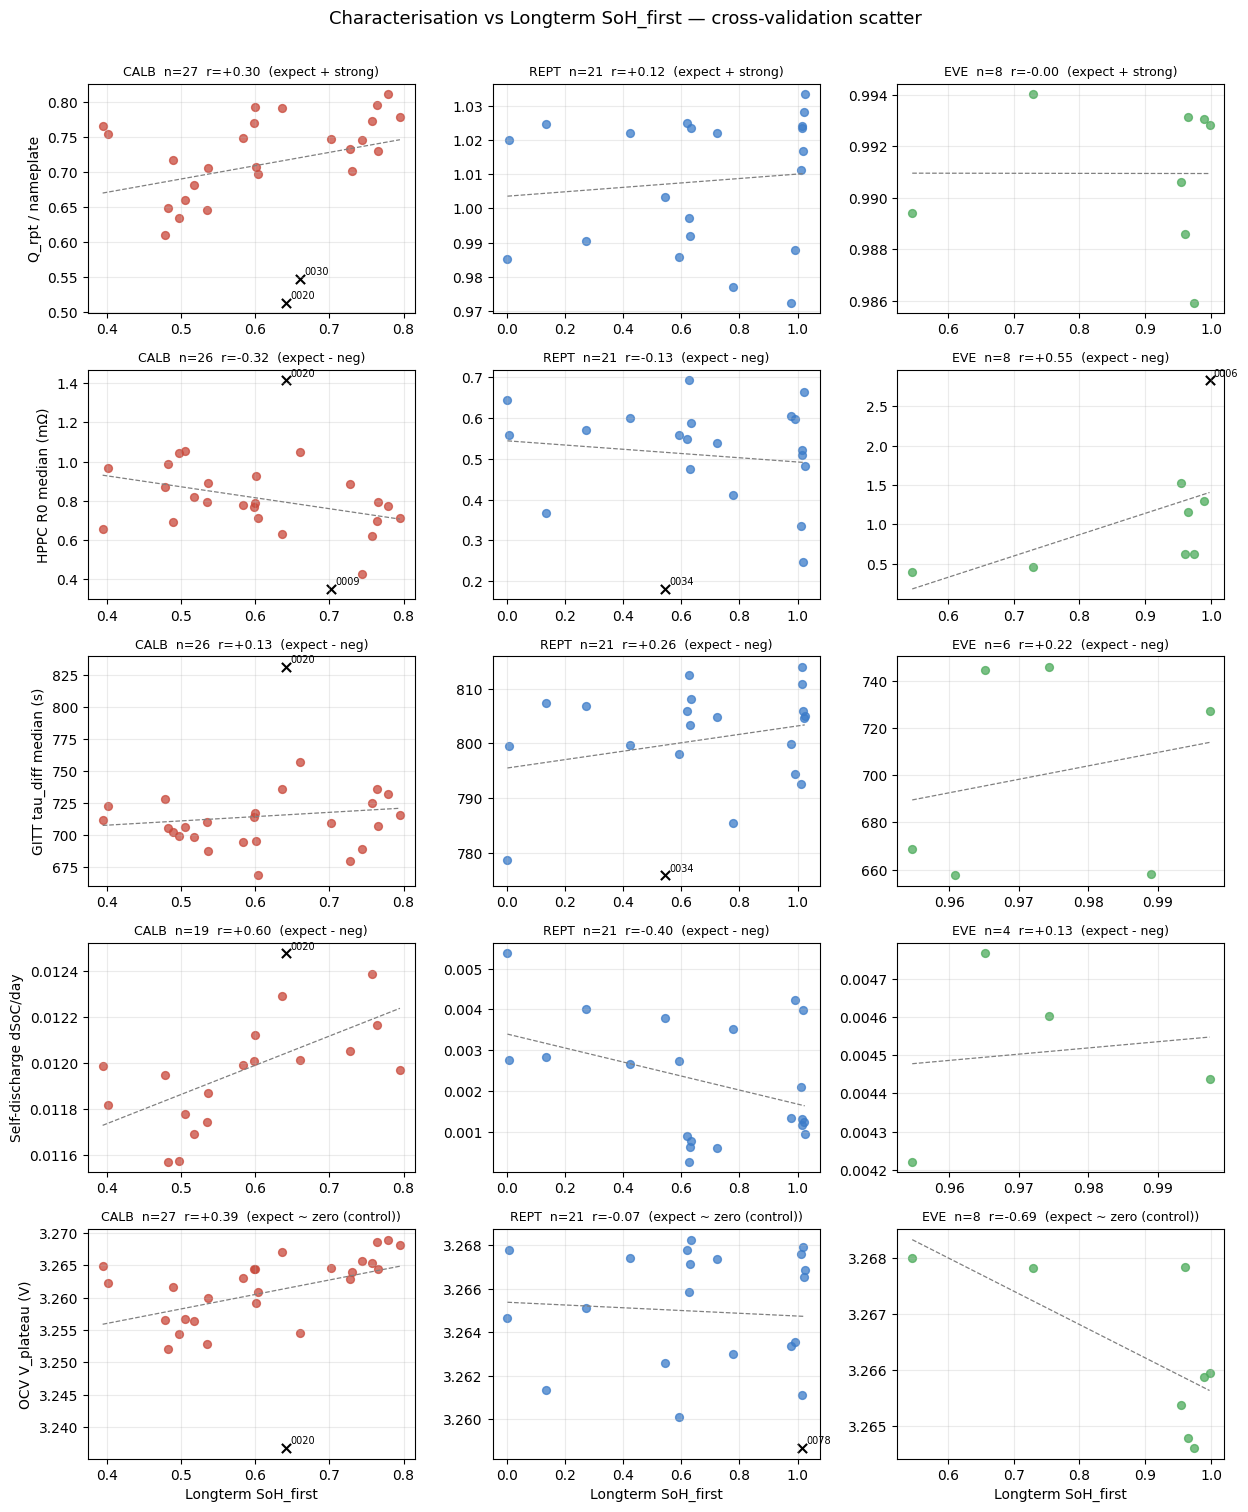

### Correlation-outlier flags: 11

,make,cell,batch,param,value,soh_first,expected,residual_z
0,CALB,0009,2,r0_median,0.350426,0.701931,0.758438,2.028914
1,CALB,0020,2,q_over_nameplate,0.513236,0.641575,0.716524,2.852164
2,CALB,0020,2,r0_median,1.413624,0.641575,0.792099,3.090647
3,CALB,0020,2,self_disch,0.012477,0.641575,0.012044,2.184790
4,CALB,0020,2,tau_median,831.218378,0.641575,715.878526,3.810189
5,CALB,0020,2,v_plat,3.236698,0.641575,3.261420,3.933986
6,CALB,0030,2,q_over_nameplate,0.547083,0.659969,0.720012,2.426226
7,EVE,0006,1,r0_median,2.831349,0.997455,1.405379,2.107607
8,REPT,0034,1,r0_median,0.181177,0.545369,0.516067,2.528412
9,REPT,0034,1,tau_median,775.827753,0.545369,799.672507,2.396955


### Cells with multiple correlation-outlier flags

,make,cell,n_flags
0,CALB,0020,5
1,REPT,0034,2


Wrote correlation-flag CSV: /home/hj/Desktop/PINNs/Voltaris/Data_Exploration/characterization_correlation_flags.csv


In [12]:
import sys as _sys
_sys.path.insert(0, '/home/hj/Desktop/PINNs/Voltaris/Data_Exploration')
from extract import calb_longterm_soh

# ---- Load SoH_first per (make, cell) ----
def _soh_first_series():
    out = {}
    for cid, tr in calb_longterm_soh().items():
        s = tr['soh'].dropna().values
        if len(s) >= 5:
            out[('CALB', cid)] = float(np.mean(s[:5]))
    for make, fname in [('EVE', 'eve.parquet'), ('REPT', 'rept.parquet')]:
        pq = pd.read_parquet(f'/home/hj/Desktop/PINNs/soh/data/canonical/{fname}')
        pq['cell'] = pq['cell_id'].astype(str).str.zfill(4)
        for c, sub in pq.groupby('cell'):
            sub = sub.sort_values('global_cycle')
            if len(sub) >= 5:
                out[(make, c)] = float(sub['soh'].iloc[:5].mean())
    return out

soh_first = _soh_first_series()

# ---- Which characterization rows to pair? ----
def _pair_batch(make):
    return {'CALB': 2, 'REPT': 1, 'EVE': 1}[make]

# Build a working table: one row per characterisation session that is pair-eligible
work = df.copy()
work = work[work.apply(lambda r: r['batch'] == _pair_batch(r['make']), axis=1)].copy()
work['soh_first'] = work.apply(
    lambda r: soh_first.get((r['make'], r['cell']), np.nan), axis=1)

# ---- Compute the paired scalars per row ----
def _median_of(a):
    if isinstance(a, np.ndarray) and a.size > 0:
        v = a[np.isfinite(a)]
        return float(np.median(v)) if v.size else np.nan
    return np.nan

work['q_over_nameplate'] = work['q_rpt_ah'] / work['nameplate_ah']
work['r0_median']        = work['r0_dchg_curve'].apply(_median_of)
work['tau_median']       = work['tau_diff_curve'].apply(_median_of)
work['v_plat']           = df.loc[work.index, 'v_plat'] if 'v_plat' in df.columns else np.nan
work['self_disch']       = work['self_disch_dsoc_per_day']

params = [
    ('q_over_nameplate', 'Q_rpt / nameplate',   '+ strong'),
    ('r0_median',        'HPPC R0 median (mΩ)', '- neg'),
    ('tau_median',       'GITT tau_diff median (s)', '- neg'),
    ('self_disch',       'Self-discharge dSoC/day', '- neg'),
    ('v_plat',           'OCV V_plateau (V)',   '~ zero (control)'),
]

# ---- Scatter plot grid: rows = params, cols = makes ----
from scipy import stats as sstats

flags_corr = []
fig, axes = plt.subplots(len(params), len(MAKES),
                          figsize=(4.2 * len(MAKES), 3.0 * len(params)),
                          sharex=False)
for i, (col, ylabel, expected) in enumerate(params):
    for j, m in enumerate(MAKES):
        ax = axes[i, j]
        sub = work[(work['make'] == m) & work['soh_first'].notna() & work[col].notna()]
        if len(sub) < 3:
            ax.text(0.5, 0.5, f'n={len(sub)} — not enough data',
                    transform=ax.transAxes, ha='center', va='center',
                    color='0.4', fontsize=9)
            ax.set_xticks([]); ax.set_yticks([])
            continue
        x = sub['soh_first'].values
        y = sub[col].values
        # Pearson r + linear fit
        r, p = sstats.pearsonr(x, y)
        slope, intercept = np.polyfit(x, y, 1)
        y_fit = slope * x + intercept
        resid = y - y_fit
        sd = np.std(resid, ddof=1) if len(resid) > 2 else np.nan
        z = np.abs(resid) / sd if sd and np.isfinite(sd) else np.zeros_like(resid)
        is_out = z > 2.0

        ax.scatter(x[~is_out], y[~is_out], color=COLOR[m], alpha=0.75, s=32)
        ax.scatter(x[is_out],  y[is_out],  color='k', s=44, marker='x',
                    linewidths=1.5, label='outlier (>2σ)')
        # trend line
        x_plot = np.linspace(x.min(), x.max(), 40)
        ax.plot(x_plot, slope * x_plot + intercept,
                color='0.5', ls='--', lw=0.9)
        # annotate outliers
        for k, is_bad in enumerate(is_out):
            if is_bad:
                ax.annotate(sub['cell'].values[k], (x[k], y[k]),
                             fontsize=7, color='k', xytext=(3, 3),
                             textcoords='offset points')
                flags_corr.append({
                    'make': m, 'cell': sub['cell'].values[k],
                    'batch': int(sub['batch'].values[k]),
                    'param': col, 'value': float(y[k]),
                    'soh_first': float(x[k]),
                    'expected': slope * x[k] + intercept,
                    'residual_z': float(z[k]),
                })
        title = f'{m}  n={len(sub)}  r={r:+.2f}  (expect {expected})'
        ax.set_title(title, fontsize=9)
        if j == 0:
            ax.set_ylabel(ylabel)
        if i == len(params) - 1:
            ax.set_xlabel('Longterm SoH_first')
        ax.grid(alpha=0.25)

fig.suptitle('Characterisation vs Longterm SoH_first — cross-validation scatter',
              fontsize=13, y=1.005)
fig.tight_layout()
plt.show()

# ---- Summary of correlation-based outliers ----
corr_flags = pd.DataFrame(flags_corr)
if not corr_flags.empty:
    display(Markdown(f'### Correlation-outlier flags: {len(corr_flags)}'))
    display(corr_flags.sort_values(['make','cell','param']).reset_index(drop=True))
    # Cells flagged more than once → strong candidates for exclusion
    counts = (corr_flags.groupby(['make','cell']).size()
                        .reset_index(name='n_flags')
                        .sort_values('n_flags', ascending=False))
    display(Markdown('### Cells with multiple correlation-outlier flags'))
    display(counts[counts['n_flags'] >= 2].reset_index(drop=True))
else:
    display(Markdown('*No correlation outliers.*'))

# Save outlier table alongside the physical-bounds decision
out_csv = Path('/home/hj/Desktop/PINNs/Voltaris/Data_Exploration/characterization_correlation_flags.csv')
corr_flags.to_csv(out_csv, index=False)
print(f'Wrote correlation-flag CSV: {out_csv}')